In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.io as io

import src.utils.utils as utils
import src.models.models as models
import src.models.foundation_models as rsfm

import sys
sys.path.append("/home/ids/edabier/HSU/DOFA")

from dofa_v1 import vit_base_patch16

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
else:
    print(f"{torch.cuda.is_available()}")
    dev = "cpu"

use_dofa = True
dataset = "jasper"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float32)
Y_flat = utils.normalize(Y_flat, dim=0)
E = torch.tensor(data["E"])
A_flat = torch.tensor(data["A"])
B, c = E.shape[0], E.shape[1]
Y = utils.oneD_to_2d(Y_flat)
A = utils.oneD_to_2d(A_flat)
Y = Y.unsqueeze(0)
A = A.unsqueeze(0)

patch_size = 16

if use_dofa:
    H = Y.shape[-1]
    if H < 224:
        Y = F.interpolate(Y, size=(224,224))
        A = F.interpolate(A, size=(224, 224))
        H = 224
    else:
        H = 224

else:
    H = int(Y_flat.shape[-1]**0.5)
    
N = H**2
Y = Y[:, :, :H, :H]
A = A[:, :, :H, :H]
Y_flat = Y.reshape(1, B, N)
A_flat = A.reshape(1, c, N)

with open(f"/home/ids/edabier/HSU/SS-HSU_benchmark/datasets/{dataset}_wavelength", "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

# four_features = True
# check_point = torch.load('/home/ids/edabier/HSU/DOFA/checkpoints/DOFA_ViT_base_e100.pth', map_location=dev)
# dofa = vit_base_patch16(four_features=four_features)
# dofa.load_state_dict(check_point, strict=False)

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may hav

In [2]:
models_list = []
cnnaeu = models.CNNAEU(B=B, c=c)

im_size = (H//patch_size)*patch_size
deep_trans = models.DeepTrans(B=B, c=c, patch_size=patch_size, im_size=im_size, embed_dim=patch_size**2)
undip = models.UnDIP(B=B, c=c)
nalmu = models.NALMU(T=25, B=B, c=c, N=N)
models_list.append(cnnaeu)
# models_list.append(deep_trans)
models_list.append(undip)
models_list.append(nalmu)

# Y_flat_trans, A_flat_trans = utils.crop_patch_image(Y_flat, patch_size, A_flat)
# Y_trans = utils.oneD_to_2d(Y_flat_trans)
# E_hat_trans, A_hat_trans, Y_hat_trans = deep_trans(Y_trans)
# print(A_hat_trans.shape)

In [3]:
estimations = {}

for model in models_list:
    model_name = model.__class__.__name__
    name = model_name

    if model_name == "RALMU" or model_name == "NALMU":
        model_name += str(model.T)
        lr = 1e-05
    else:
        lr = 0.003

    if model_name == "DeepTrans":
        Y_flat, A_flat = utils.crop_patch_image(Y_flat, patch_size, A_flat)

    state_dict = torch.load(f"/home/ids/edabier/HSU/SS-HSU_benchmark/models/{model_name}_Basic_{dataset}_lr_{lr}.pt", map_location=dev)["model_state_dict"]
    model.load_state_dict(state_dict, strict=False)

    E_hat, A_hat, Y_hat = model(Y_flat)
    Y_hat = utils.normalize(Y_hat, dim=1)
    A_hat = utils.normalize(A_hat, dim=1)
    E_hat = utils.normalize(E_hat, dim=0)
    Y_hat = utils.oneD_to_2d(Y_hat)
    A_hat = utils.oneD_to_2d(A_hat)
    
    
    E_hat, _, A_hat, indices = utils.order_endmembers(E, E_hat, A_hat)
    estimations[name] = [Y_hat, A_hat, E_hat]

Y_hat = E @ A_flat
Y_hat = utils.oneD_to_2d(Y_hat)
Y_hat = utils.normalize(Y_hat[0]).unsqueeze(0)
estimations["GT"] = [Y_hat, A, E]

In [4]:
sims = {}
sad_loss = utils.SADLoss()

if use_dofa:
    features = rsfm.get_dofa_features(Y, wavelengths)
    features = features.reshape(768, 14, 14)
else:
    features = rsfm.get_hypersigma_features(Y, c, patch_size=128, keep_dim=True)

for model in models_list:
    name = model.__class__.__name__
    Y_hat = estimations[name][0]
    A_hat = estimations[name][1]
    E_hat = estimations[name][2]

    mse, sad, mse_y = utils.compute_metrics(E, A, E_hat, A_hat, Y, Y_hat)
    metric = mse+sad+mse_y

    # features = rsfm.get_hypersigma_features(Y, c)
    if use_dofa:
        features_hat = rsfm.get_dofa_features(Y_hat.to(torch.float),wavelengths)
        features_hat = features_hat.reshape(768, 14, 14)
    else:
        features_hat = rsfm.get_hypersigma_features(Y_hat.to(torch.float),c, patch_size=128, keep_dim=True)

    sim = sad_loss(features, features_hat)
    # sim = rsfm.features_comparison("HyperSIGMA", Y, Y_hat, c=c).item()
    sims[name] = [features, features_hat, sim, mse, sad, mse_y]
    # print(f"{name} features distance: {format(sim, '.3f')}, mse: {format(mse, '.3f')}, sad: {format(sad, '.3f')}, sum={format(metric, '.3f')}")

Y_hat = estimations["GT"][0]
A_hat = estimations["GT"][1]
E_hat = estimations["GT"][2]
mse, sad, mse_y = utils.compute_metrics(E, A, E_hat, A_hat, Y, Y_hat)
metric = mse+sad+mse_y

# features = rsfm.get_hypersigma_features(Y, c)
if use_dofa:
    features_hat = rsfm.get_dofa_features(Y_hat.to(torch.float),wavelengths)
    features_hat = features_hat.reshape(768, 14, 14)
else:
    features_hat = rsfm.get_hypersigma_features(Y_hat.to(torch.float), c , patch_size=128, keep_dim=True)
sim = sad_loss(features, features_hat)
sims["GT"] = [features, features_hat, sim, mse, sad, mse_y]

# sim = rsfm.features_comparison("HyperSIGMA", Y.to(torch.float), Y_hat.to(torch.float), c=c).item()
# print(f"{'GT'} features distance: {format(sim, '.3f')}, mse: {format(mse, '.3f')}, sad: {format(sad, '.3f')}, sum={format(metric, '.3f')}")

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/torch/utils/_device.py:103: UserWarning: Using a target size (torch.Size([4, 224, 224])) that is different to the input size (torch.Size([1, 4, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return func(*args, **kwargs)


[tensor(0.6283, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(1.2068, device='cuda:0', dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor(0.4955, device='cuda:0', dtype=torch.float64),
 tensor(0.6239, device='cuda:0', grad_fn=<DivBackward0>)]

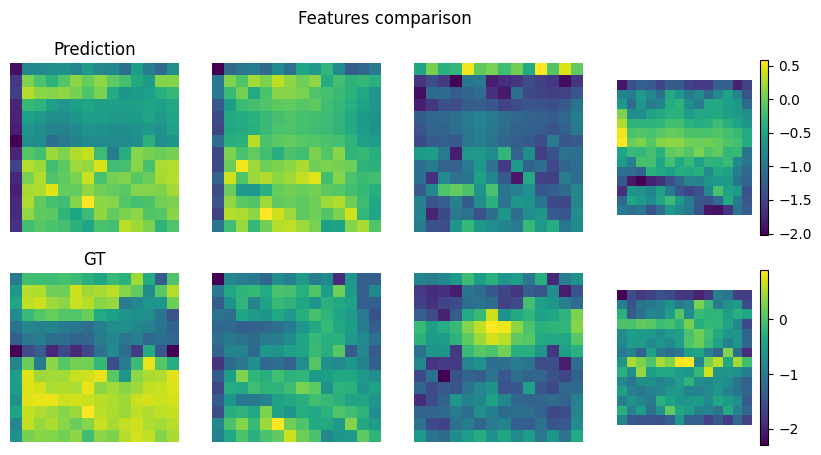

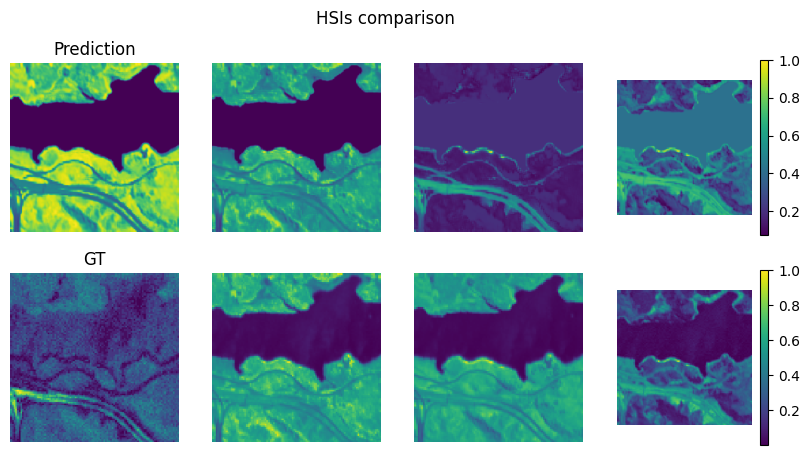

In [8]:
name = 'UnDIP'

utils.compare_hsis(features, sims[name][1], title="Features comparison")
utils.compare_hsis(Y, estimations[name][0], title="HSIs comparison")
sims[name][2:]

/home/ids/edabier/HSU/SS-HSU_benchmark/src/utils/utils.py:334: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


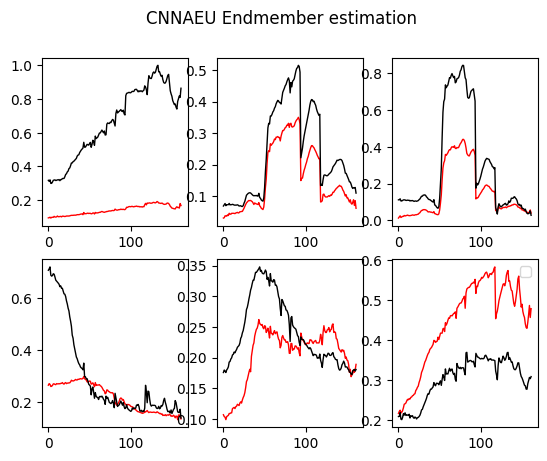

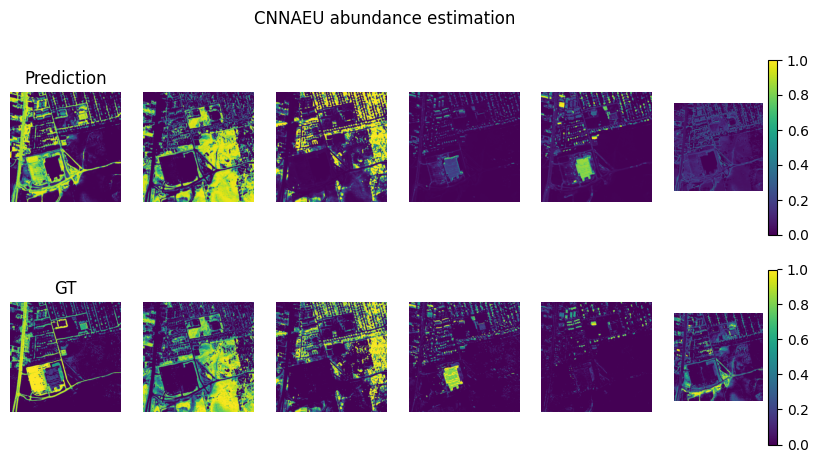

In [6]:
name = "CNNAEU"
utils.plot_results(estimations[name][2], estimations[name][1], A, E, model_name=name)